In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from src.config import get_path, get_sample_window

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_P1 = get_path('data_phase1')
DATA_P2 = get_path('data_phase2')
DATA_P3 = get_path('data_phase3')
RES_P3 = get_path('results_phase3')

TAB = RES_P3 / 'tables'
FIG = RES_P3 / 'figures'

summary = pd.read_csv(TAB / 'phase3_summary.csv')
print(summary[['venue','spec','n_days','n_params','kl_mean','converged',
               'mean_c','c_low','c_mid','c_high']].to_string(index=False))

venue   spec  n_days  n_params   kl_mean  converged     mean_c      c_low      c_mid     c_high
  CME crypto     624        12 -0.281042       True -13.226869 -17.432982 -12.172588  -9.658304
  CME  macro     624        15 -0.277461      False -10.378673 -10.803865  -8.373877 -11.787768
  CME   full     624        24 -0.288019      False  -9.025212  -8.971247  -9.312196  -8.816035
  DER crypto     765        12 -0.250259       True -12.336012 -16.819415 -11.530871  -8.604796
  DER  macro     765        15 -0.248853      False  -9.815150 -11.244061  -7.756415 -10.428095
  DER   full     765        24 -0.258849      False  -8.372543  -8.979213  -8.514494  -7.616756


#### 1. Estimation Diagnostics

Key checks: convergence status, KL mean (lower = better fit), and the
curvature coefficient across terciles.

Notes: (i) the reported `kl_mean` is a cross-entropy (not a true KL
divergence), so negative values are expected and do not indicate a
numerical problem; (ii) do NOT read hump presence off the marginal `c`
in the cubic family — the economically meaningful object is the
curvature at the money (2c + 6d at R = 1), tested formally by
`joint_regime_test.py`.

In [3]:
display_cols = ['venue', 'spec', 'converged', 'kl_mean',
                'mean_b', 'std_b', 'mean_c', 'std_c', 'mean_d', 'std_d',
                'c_low', 'c_mid', 'c_high']
avail = [c for c in display_cols if c in summary.columns]
print(summary[avail].round(4).to_string(index=False))

venue   spec  converged  kl_mean  mean_b  std_b   mean_c  std_c  mean_d  std_d    c_low    c_mid   c_high
  CME crypto       True  -0.2810 14.2178 9.0463 -13.2269 7.2326  3.6734 1.9644 -17.4330 -12.1726  -9.6583
  CME  macro      False  -0.2775 11.5681 7.1734 -10.3787 6.1094  2.6803 2.3582 -10.8039  -8.3739 -11.7878
  CME   full      False  -0.2880 10.6536 8.9195  -9.0252 7.7480  2.1110 2.8047  -8.9712  -9.3122  -8.8160
  DER crypto       True  -0.2503 12.4436 8.6758 -12.3360 6.8790  3.6496 1.8202 -16.8194 -11.5309  -8.6048
  DER  macro      False  -0.2489 10.2505 7.5169  -9.8151 5.9041  2.7265 2.1338 -11.2441  -7.7564 -10.4281
  DER   full      False  -0.2588  9.2127 8.3158  -8.3725 6.8100  2.1354 2.4740  -8.9792  -8.5145  -7.6168


#### 2. Kernel at Volatility Terciles (crypto spec)

Kernels are normalized **mean-one under the Phase 2 physical density**
(the model's own normalization, m = q~/p), so they are directly
comparable to the Phase 2 unconditional q/p kernel. Tercile labels are
loaded from the saved `.npz` (full-sample Z_IVS_1 `pd.qcut(q=3)`,
shared with Phases 4 and 5); if the `.npz` predates the fix, labels are
recomputed by date-aligning Z_crypto with the saved dates.

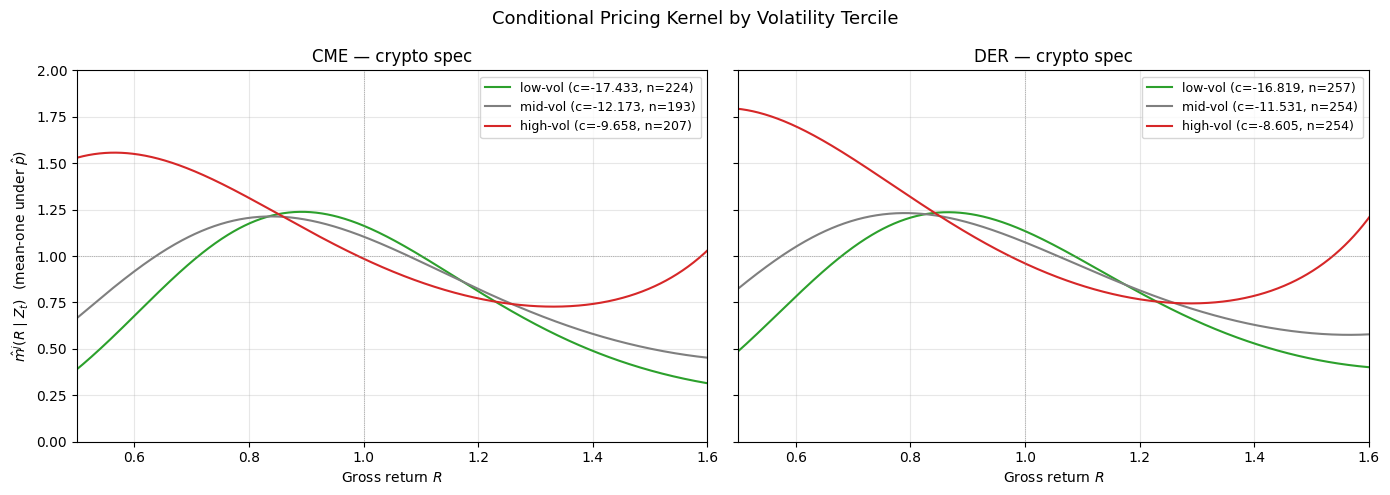

In [4]:
from src.phase3.conditional_kernel import (
    ConditionalKernelResult, evaluate_kernel_at_terciles
)
from src.config import get_return_grid

R_GRID = get_return_grid()
colors = {'low': 'C2', 'mid': 'C7', 'high': 'C3'}

p_phys = np.load(DATA_P2 / 'phase2_densities.npz')['p_almeida']
Z_crypto = pd.read_parquet(DATA_P1 / 'Z_crypto.parquet')

Z_crypto['date'] = pd.to_datetime(Z_crypto['date'])
z_cols = [c for c in Z_crypto.columns if c != 'date' and not c.endswith('_raw')]
Z_crypto['tercile'] = pd.qcut(Z_crypto['Z_IVS_1'], q=3, labels=['low', 'mid', 'high'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, venue in zip(axes, ['CME', 'DER']):
    key = f'{venue}_crypto'
    data = np.load(DATA_P3 / f'phase3_{key}.npz', allow_pickle=True)
    row = summary[(summary['venue']==venue) & (summary['spec']=='crypto')].iloc[0]
    dates_run = pd.to_datetime(data['dates'])

    if 'tercile_labels' in data:
        tercile_labels = data['tercile_labels'].astype(object)
    else:
        run_df = pd.DataFrame({'date': dates_run})
        merged = run_df.merge(Z_crypto[['date', 'tercile']], on='date', how='inner')
        tercile_labels = merged['tercile'].astype(object).values
        print(f"  [{venue}] WARNING: npz has no tercile_labels — recomputed "
              f"from date-aligned Z_crypto ({len(merged)} days)")

    run_df = pd.DataFrame({'date': dates_run})
    merged_z = run_df.merge(Z_crypto[['date'] + z_cols], on='date', how='inner')
    Z_mat = merged_z[z_cols].values

    result = ConditionalKernelResult(
        theta=data['theta'], n_params=int(row['n_params']),
        n_days=int(row['n_days']), n_Z=len(z_cols), venue=venue,
        spec_name='crypto', kl_total=row['kl_total'],
        kl_mean=row['kl_mean'], converged=row['converged'], hessian_inv=None)
    terciles = evaluate_kernel_at_terciles(result, R_GRID, Z_mat,
                                           tercile_labels=tercile_labels,
                                           p_phys=p_phys)
    for name in ['low', 'mid', 'high']:
        if name not in terciles:
            continue
        t = terciles[name]
        ax.plot(R_GRID, t['kernel'], color=colors[name], lw=1.5,
                label=f"{name}-vol (c={t['c']:.3f}, n={t['n_days']})")
        if 'p_mean_check' in t:
            assert abs(t['p_mean_check'] - 1.0) < 1e-6
    ax.axhline(1.0, color='gray', lw=0.5, ls=':')
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_ylim(0, 2)
    ax.set_title(f'{venue} — crypto spec')
    ax.legend(fontsize=9)
axes[0].set_ylabel(r'$\hat{m}^j(R \mid Z_t)$  (mean-one under $\hat{p}$)')
fig.suptitle('Conditional Pricing Kernel by Volatility Tercile', fontsize=13)
plt.tight_layout()
plt.show()

#### 3. Coefficient Time Series (crypto spec)

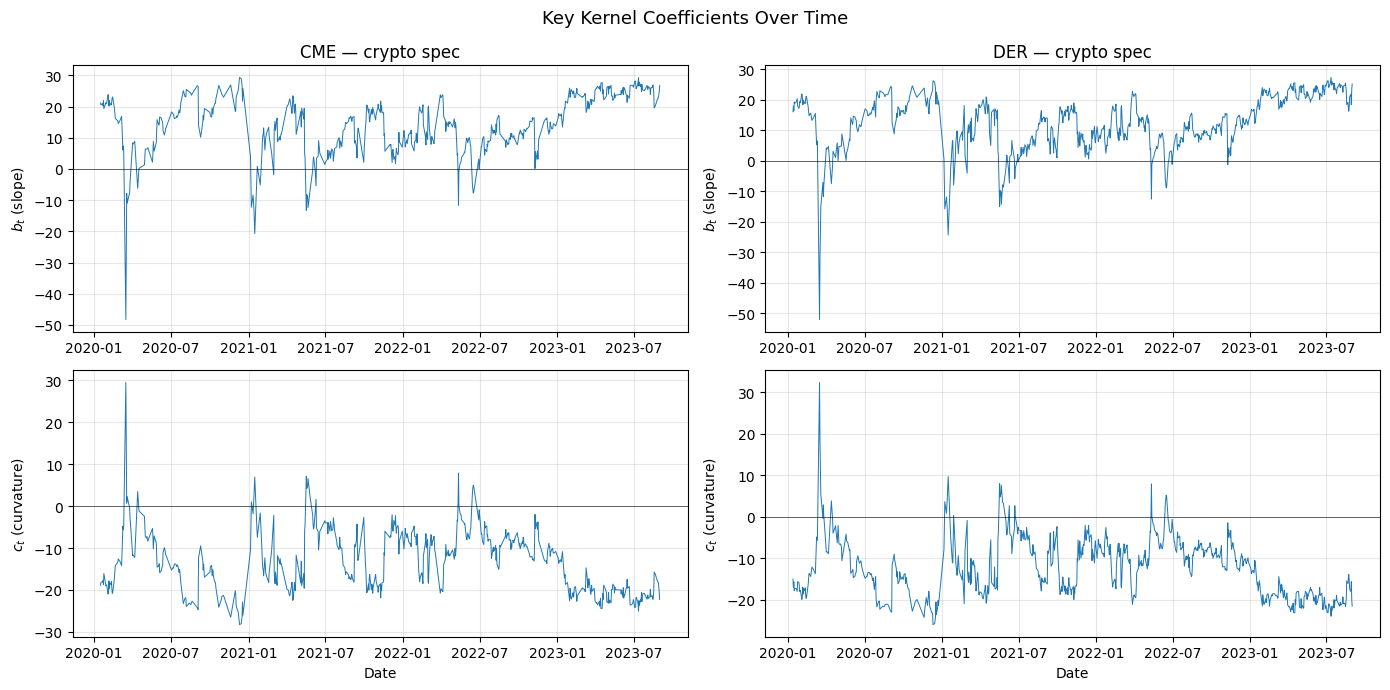

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for venue, col_offset in [('CME', 0), ('DER', 1)]:
    data = np.load(DATA_P3 / f'phase3_{venue}_crypto.npz', allow_pickle=True)
    dates = pd.to_datetime(data['dates'])
    for row_idx, (coeff, label) in enumerate([
        ('coeffs_b', '$b_t$ (slope)'), ('coeffs_c', '$c_t$ (curvature)')
    ]):
        ax = axes[row_idx, col_offset]
        ax.plot(dates, data[coeff], lw=0.7, color='C0')
        ax.axhline(0, color='black', lw=0.4)
        ax.set_ylabel(label)
        if row_idx == 0:
            ax.set_title(f'{venue} — crypto spec')
for ax in axes[-1]:
    ax.set_xlabel('Date')
plt.suptitle('Key Kernel Coefficients Over Time', fontsize=13)
plt.tight_layout()
plt.show()

#### 4. Unconditional Microstructure Friction Kernel

$\Psi(R) = \log(\hat{q}^{\mathrm{CME}}(R) / \hat{q}^{\mathrm{DER}}(R))$.
Positive values mean CME prices that return state more expensively than
Deribit. `mfk_std` in the npz is the bootstrap SE of the mean (std of B
bootstrap means), NOT the raw daily std — it is used directly, never
divided by sqrt(n) again. The saved `mfk_lo`/`mfk_hi` percentile bands
are preferred when available.

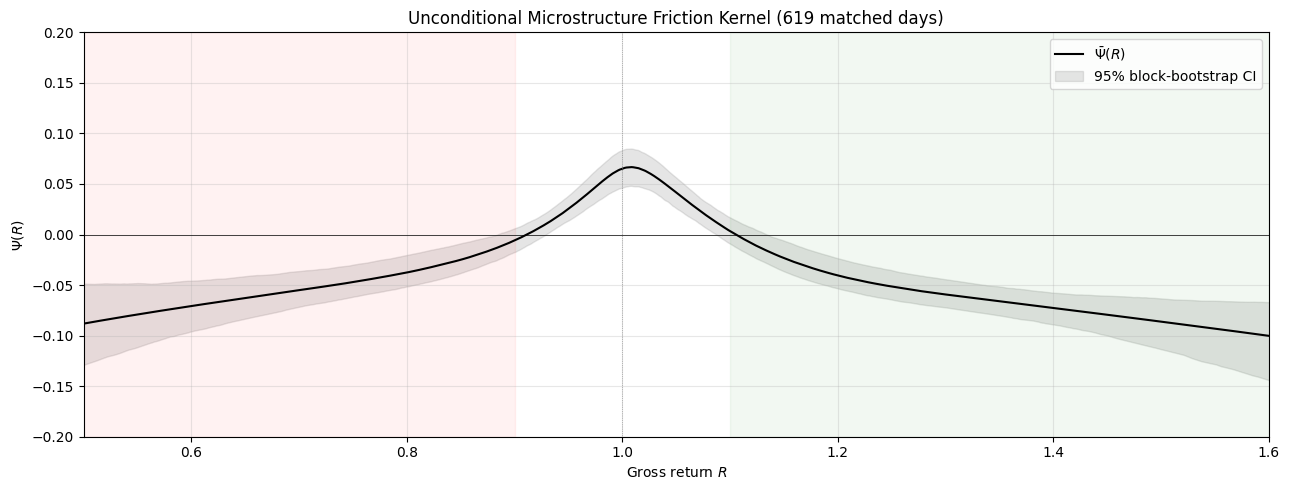

In [6]:
mfk = np.load(DATA_P3 / 'mfk_unconditional.npz')
R_mfk = mfk['R_grid']
psi = mfk['mfk_mean']

if 'mfk_lo' in mfk and 'mfk_hi' in mfk:
    ci_lo, ci_hi = mfk['mfk_lo'], mfk['mfk_hi']
    ci_label = '95% block-bootstrap CI'
else:
    psi_se = mfk['mfk_std']   # already SE of the mean
    ci_lo, ci_hi = psi - 1.96 * psi_se, psi + 1.96 * psi_se
    ci_label = '95% CI (normal approx)'

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R_mfk, psi, 'k-', lw=1.5, label=r'$\bar{\Psi}(R)$')
ax.fill_between(R_mfk, ci_lo, ci_hi, alpha=0.2, color='gray', label=ci_label)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.axvspan(R_mfk[0], 0.90, alpha=0.05, color='red')
ax.axvspan(1.10, R_mfk[-1], alpha=0.05, color='green')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\Psi(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_ylim(-0.2, 0.2)
ax.set_title(f'Unconditional Microstructure Friction Kernel ({int(mfk["n_days"])} matched days)')
ax.legend()
plt.tight_layout()
plt.show()

#### 5. Specification Comparison: KL Fit Quality

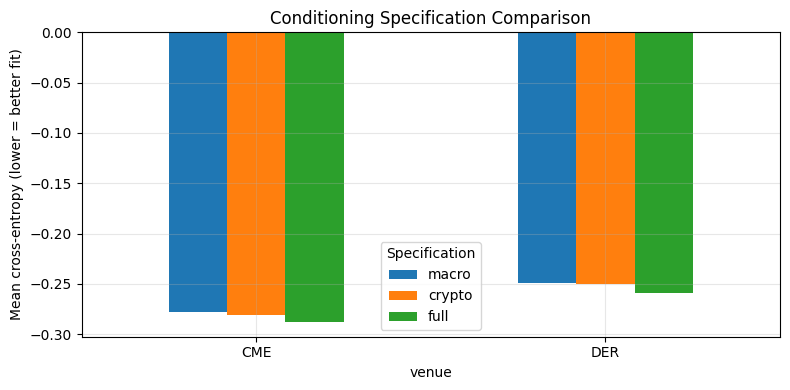


Convergence status:
spec   crypto   full  macro
venue                      
CME      True  False  False
DER      True  False  False


In [7]:
kl_pivot = summary.pivot(index='venue', columns='spec', values='kl_mean')
kl_pivot = kl_pivot[['macro', 'crypto', 'full']]

fig, ax = plt.subplots(figsize=(8, 4))
kl_pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('Mean cross-entropy (lower = better fit)')
ax.set_title('Conditioning Specification Comparison')
ax.legend(title='Specification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nConvergence status:')
print(summary.pivot(index='venue', columns='spec', values='converged').to_string())